In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

## Volcano Plots for DEG (PDS+IDS not corrected for chemotherapy status,PDS+IDS corrected for chemotherapy status, IDS)

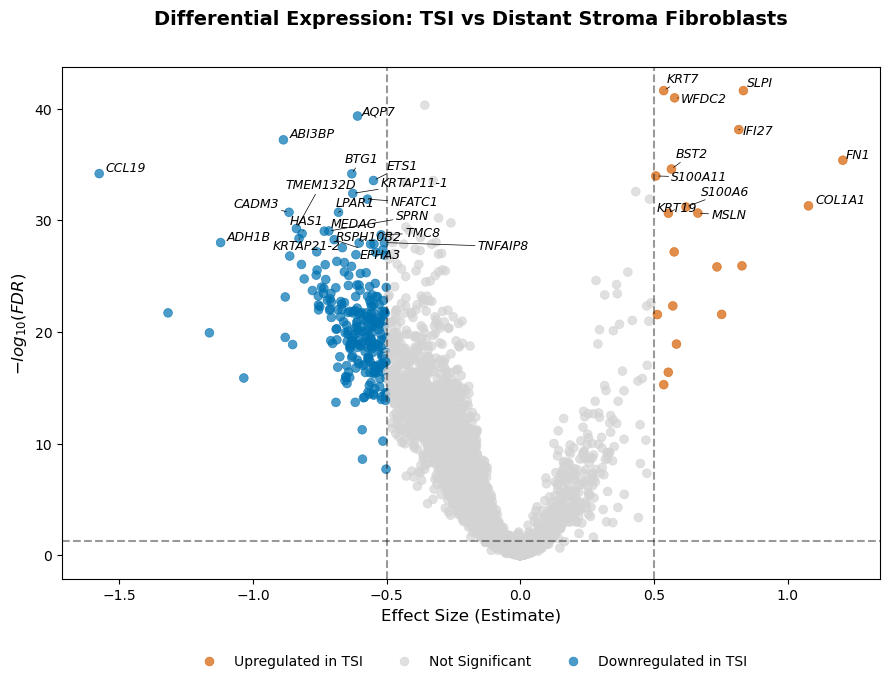

Editable SVG plot saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR.svg


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
df = pd.read_csv("/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_tsi_stroma.csv")

# --- 2. Define Cutoffs ---
fdr_cutoff = 0.05  
fc_cutoff = 0.5    

# --- 3. Categorize Significance ---
def categorize_sig(row):
    if row['FDR'] < fdr_cutoff and row['Estimate'] > fc_cutoff:
        return "Upregulated in TSI"
    elif row['FDR'] < fdr_cutoff and row['Estimate'] < -fc_cutoff:
        return "Downregulated in TSI"
    else:
        return "Not Significant"

df['Significance'] = df.apply(categorize_sig, axis=1)

# Create the -log10 FDR for the Y-axis
df['-log10(FDR)'] = -np.log10(df['FDR'].clip(lower=1e-300))

# --- 4. Isolate Top Genes for Labeling ---
# Grab the top 30 most significant genes by FDR that passed both thresholds
top_genes = df[df['Significance'] != "Not Significant"].sort_values('FDR').head(30)

# --- 5. Build Plot ---
plt.figure(figsize=(9, 7))

custom_palette = {
    "Upregulated in TSI": "#D55E00", 
    "Downregulated in TSI": "#0072B2", 
    "Not Significant": "lightgrey"
}

sns.scatterplot(
    data=df, 
    x='Estimate', 
    y='-log10(FDR)', 
    hue='Significance', 
    palette=custom_palette, 
    alpha=0.7, 
    edgecolor=None,
    s=40
)

# Add threshold lines
plt.axvline(x=fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axvline(x=-fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axhline(y=-np.log10(fdr_cutoff), color='black', linestyle='--', alpha=0.4) 

# Add non-overlapping labels
texts = []
for idx, row in top_genes.iterrows():
    texts.append(plt.text(row['Estimate'], row['-log10(FDR)'], row['Gene'], 
                          fontsize=9, style='italic', color='black'))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5))

# Formatting
plt.title("Differential Expression: TSI vs Distant Stroma Fibroblasts\n", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Effect Size (Estimate)", fontsize=12)
plt.ylabel(r"$-log_{10}(FDR)$", fontsize=12) 

plt.legend(title="", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
plt.tight_layout()

# --- 6. Save Plot ---
# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG plot saved successfully to:\n{save_path}")

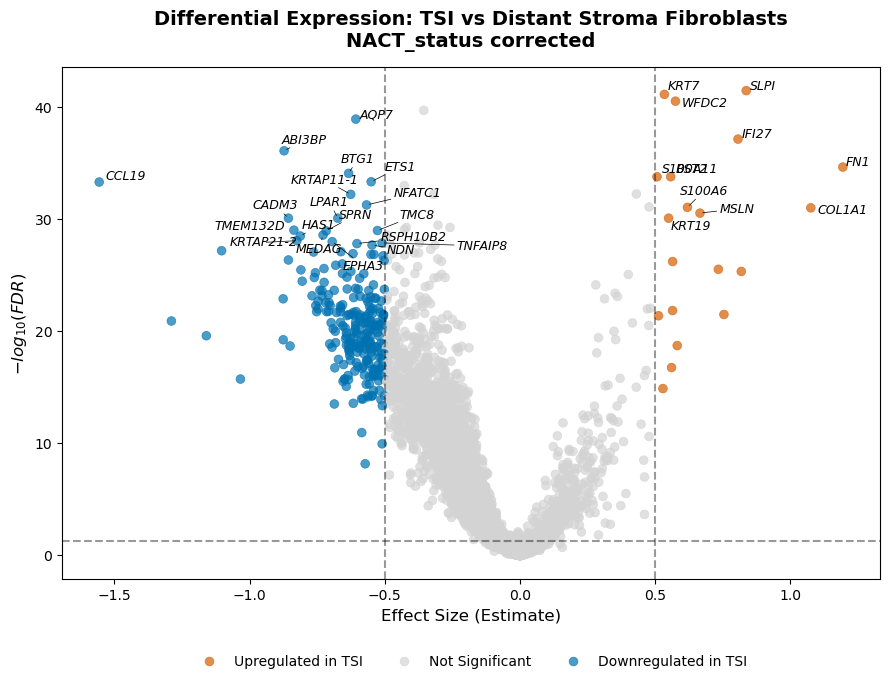

Editable SVG plot saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_NACT_corrected.svg


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
# Note: Added the missing '/' at the start of your file path just in case!
df = pd.read_csv("/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_DEG_tsi_stroma_corrected_for_chemo_and_sample.csv")

# --- 2. Define Cutoffs ---
fdr_cutoff = 0.05  
fc_cutoff = 0.5    

# --- 3. Categorize Significance ---
def categorize_sig(row):
    if row['FDR'] < fdr_cutoff and row['Estimate'] > fc_cutoff:
        return "Upregulated in TSI"
    elif row['FDR'] < fdr_cutoff and row['Estimate'] < -fc_cutoff:
        return "Downregulated in TSI"
    else:
        return "Not Significant"

df['Significance'] = df.apply(categorize_sig, axis=1)

# Create the -log10 FDR for the Y-axis
df['-log10(FDR)'] = -np.log10(df['FDR'].clip(lower=1e-300))

# --- 4. Isolate Top Genes for Labeling ---
# Grab the top 30 most significant genes by FDR that passed both thresholds
top_genes = df[df['Significance'] != "Not Significant"].sort_values('FDR').head(30)

# --- 5. Build Plot ---
plt.figure(figsize=(9, 7))

custom_palette = {
    "Upregulated in TSI": "#D55E00", 
    "Downregulated in TSI": "#0072B2", 
    "Not Significant": "lightgrey"
}

sns.scatterplot(
    data=df, 
    x='Estimate', 
    y='-log10(FDR)', 
    hue='Significance', 
    palette=custom_palette, 
    alpha=0.7, 
    edgecolor=None,
    s=40
)

# Add threshold lines
plt.axvline(x=fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axvline(x=-fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axhline(y=-np.log10(fdr_cutoff), color='black', linestyle='--', alpha=0.4) 

# Add non-overlapping labels
texts = []
for idx, row in top_genes.iterrows():
    texts.append(plt.text(row['Estimate'], row['-log10(FDR)'], row['Gene'], 
                          fontsize=9, style='italic', color='black'))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5))

# Formatting
plt.title("Differential Expression: TSI vs Distant Stroma Fibroblasts\nNACT_status corrected", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Effect Size (Estimate)", fontsize=12)
plt.ylabel(r"$-log_{10}(FDR)$", fontsize=12) 

plt.legend(title="", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
plt.tight_layout()

# --- 6. Save Plot ---
# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_NACT_corrected.svg"

plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG plot saved successfully to:\n{save_path}")

Calculating label positions for 20 genes. This might take a moment...


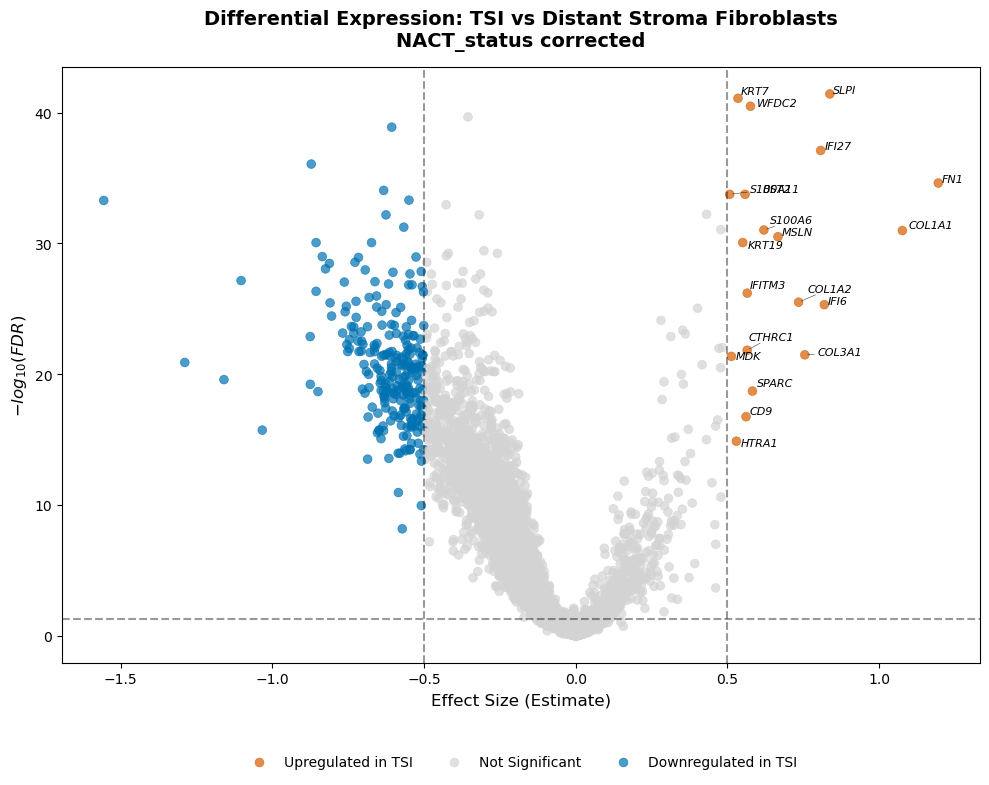

Editable SVG plot saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_NACT_corrected_ALL_TSI.svg


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
df = pd.read_csv("/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_DEG_tsi_stroma_corrected_for_chemo_and_sample.csv")

# --- 2. Define Cutoffs ---
fdr_cutoff = 0.05  
fc_cutoff = 0.5    

# --- 3. Categorize Significance ---
def categorize_sig(row):
    if row['FDR'] < fdr_cutoff and row['Estimate'] > fc_cutoff:
        return "Upregulated in TSI"
    elif row['FDR'] < fdr_cutoff and row['Estimate'] < -fc_cutoff:
        return "Downregulated in TSI"
    else:
        return "Not Significant"

df['Significance'] = df.apply(categorize_sig, axis=1)

df['-log10(FDR)'] = -np.log10(df['FDR'].clip(lower=1e-300))

# --- 4. Isolate Genes for Labeling ---
# Filter specifically for ALL genes upregulated in the TSI (no .head() limit)
top_genes = df[df['Significance'] == "Upregulated in TSI"]

# --- 5. Build Plot ---
plt.figure(figsize=(10, 8)) # Made slightly larger to accommodate more text

custom_palette = {
    "Upregulated in TSI": "#D55E00", 
    "Downregulated in TSI": "#0072B2", 
    "Not Significant": "lightgrey"
}

sns.scatterplot(
    data=df, 
    x='Estimate', 
    y='-log10(FDR)', 
    hue='Significance', 
    palette=custom_palette, 
    alpha=0.7, 
    edgecolor=None,
    s=40
)

# Add threshold lines
plt.axvline(x=fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axvline(x=-fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axhline(y=-np.log10(fdr_cutoff), color='black', linestyle='--', alpha=0.4) 

# Add non-overlapping labels
texts = []
for idx, row in top_genes.iterrows():
    # Reduced fontsize slightly to help fit all the labels
    texts.append(plt.text(row['Estimate'], row['-log10(FDR)'], row['Gene'], 
                          fontsize=8, style='italic', color='black'))

print(f"Calculating label positions for {len(texts)} genes. This might take a moment...")
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.3))

# Formatting
plt.title("Differential Expression: TSI vs Distant Stroma Fibroblasts\nNACT_status corrected", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Effect Size (Estimate)", fontsize=12)
plt.ylabel(r"$-log_{10}(FDR)$", fontsize=12) 

plt.legend(title="", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
plt.tight_layout()

# --- 6. Save Plot ---
# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_NACT_corrected_ALL_TSI.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG plot saved successfully to:\n{save_path}")

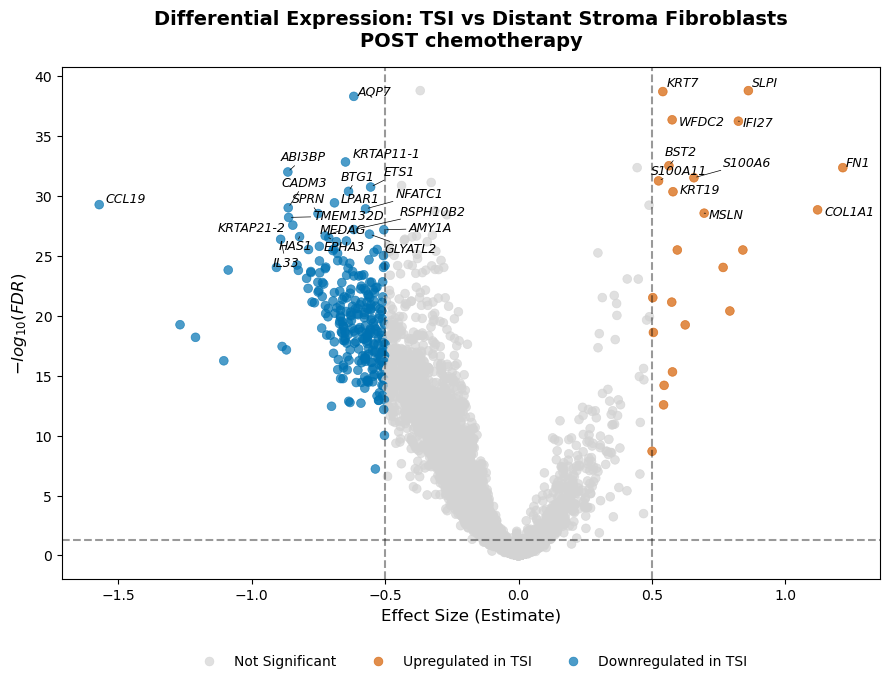

Editable SVG plot saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_POST_ONLY.svg


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
df = pd.read_csv("/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_tsi_stroma_POST_ONLY.csv")

# --- 2. Define Cutoffs ---
fdr_cutoff = 0.05  
fc_cutoff = 0.5    

# --- 3. Categorize Significance ---
def categorize_sig(row):
    if row['FDR'] < fdr_cutoff and row['Estimate'] > fc_cutoff:
        return "Upregulated in TSI"
    elif row['FDR'] < fdr_cutoff and row['Estimate'] < -fc_cutoff:
        return "Downregulated in TSI"
    else:
        return "Not Significant"

df['Significance'] = df.apply(categorize_sig, axis=1)

# Create the -log10 FDR for the Y-axis
df['-log10(FDR)'] = -np.log10(df['FDR'].clip(lower=1e-300))

# --- 4. Isolate Top Genes for Labeling ---
# Grab the top 30 most significant genes by FDR that passed both thresholds
top_genes = df[df['Significance'] != "Not Significant"].sort_values('FDR').head(30)

# --- 5. Build Plot ---
plt.figure(figsize=(9, 7))

custom_palette = {
    "Upregulated in TSI": "#D55E00", 
    "Downregulated in TSI": "#0072B2", 
    "Not Significant": "lightgrey"
}

sns.scatterplot(
    data=df, 
    x='Estimate', 
    y='-log10(FDR)', 
    hue='Significance', 
    palette=custom_palette, 
    alpha=0.7, 
    edgecolor=None,
    s=40
)

# Add threshold lines
plt.axvline(x=fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axvline(x=-fc_cutoff, color='black', linestyle='--', alpha=0.4)
plt.axhline(y=-np.log10(fdr_cutoff), color='black', linestyle='--', alpha=0.4) 

# Add non-overlapping labels
texts = []
for idx, row in top_genes.iterrows():
    texts.append(plt.text(row['Estimate'], row['-log10(FDR)'], row['Gene'], 
                          fontsize=9, style='italic', color='black'))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5))

# Formatting
plt.title("Differential Expression: TSI vs Distant Stroma Fibroblasts\nPOST chemotherapy", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Effect Size (Estimate)", fontsize=12)
plt.ylabel(r"$-log_{10}(FDR)$", fontsize=12) 

plt.legend(title="", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
plt.tight_layout()

# --- 6. Save Plot ---
# Changed filename to specify it uses FDR, POST_ONLY, and exports as an SVG
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Volcano_TSI_vs_Stroma_Python_FDR_POST_ONLY.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG plot saved successfully to:\n{save_path}")

## Heatmaps with Differentially Expressed Genes

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


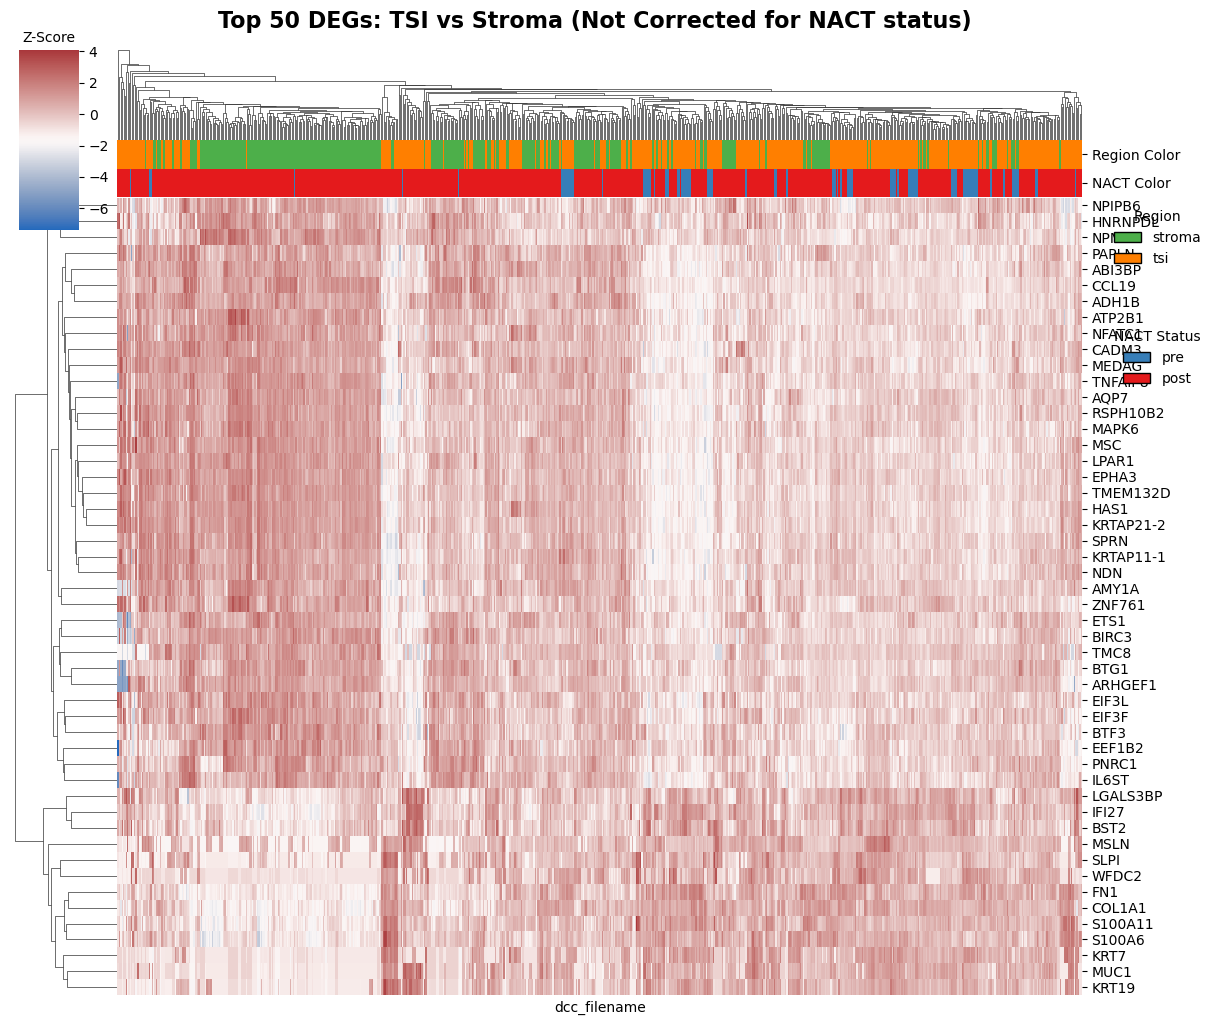

Editable SVG heatmap saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_not_NACT_corrected.svg


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
results_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_tsi_stroma.csv"
expr_path = "/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv"
meta_path = "/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.xlsx"

df_results = pd.read_csv(results_path)
raw_expression = pd.read_csv(expr_path)
metadata = pd.read_excel(meta_path, engine='openpyxl')

# --- 2. Get Top Genes ---
# Let's take the top 50 most significant genes by FDR for a clean heatmap
num_genes_to_plot = 50
top_genes = df_results.sort_values('FDR').head(num_genes_to_plot)['Gene'].tolist()

# --- 3. Prep the Data ---
# Merge expression and metadata
df_merged = pd.merge(raw_expression, metadata, on="dcc_filename", how="left")

# Apply the same strict filtering we used for the LMM analysis
df_filtered = df_merged[
    (df_merged['Segment'] == 'stroma') & 
    (df_merged['Segment_geomx'].isin(['stroma', 'tsi']))
].copy()

# Drop rows with missing annotation data so it doesn't break the heatmap
df_filtered = df_filtered.dropna(subset=['Segment_geomx', 'NACT_status'])

# Extract just the top genes for the heatmap matrix
# Set dcc_filename as index so it becomes the column names of the heatmap
heatmap_data = df_filtered.set_index('dcc_filename')[top_genes]

# Transpose so genes are rows and samples are columns (Standard Biology Format)
heatmap_data = heatmap_data.T 

# Convert all data to numeric just in case
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')

# --- 4. Create Annotations (Color Bars) ---
# Extract the metadata for the samples in our heatmap
col_meta = df_filtered.set_index('dcc_filename')[['Segment_geomx', 'NACT_status']]

# Define color dictionaries for your categories
region_colors = {"stroma": "#4daf4a", "tsi": "#ff7f00"}   # Green and Orange
nact_colors = {"pre": "#377eb8", "post": "#e41a1c"}       # Blue and Red

# Map the colors to the samples
col_meta['Region Color'] = col_meta['Segment_geomx'].map(region_colors)
col_meta['NACT Color'] = col_meta['NACT_status'].map(nact_colors)

# The clustermap needs just the color columns
network_colors = col_meta[['Region Color', 'NACT Color']]

# --- 5. Build and Plot the Clustermap ---
# z_score=0 normalizes data across rows (genes) so high/low expressors are on the same visual scale
g = sns.clustermap(
    heatmap_data, 
    cmap="vlag",             # Blue (low) to Red (high) color scale
    z_score=0,               # Z-score normalize across genes
    col_colors=network_colors, 
    figsize=(12, 10), 
    xticklabels=False,       # Hide sample names (too crowded)
    yticklabels=True,        # Show gene names
    cbar_pos=(0.02, 0.8, 0.05, 0.18), # Position of colorbar legend
    dendrogram_ratio=(0.1, 0.1)
)

# Label the colorbar
g.ax_cbar.set_title('Z-Score', fontsize=10)

# --- 6. Add Custom Legends for the Annotations ---
# Because clustermap doesn't auto-legend the top color bars, we add them manually
# Create legend handles for Region
region_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                  for label, color in region_colors.items()]

# Create legend handles for NACT
nact_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                for label, color in nact_colors.items()]

# Add Region Legend
l1 = g.ax_heatmap.legend(
    handles=region_handles, title='Region',
    loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False
)
# Add NACT Legend
l2 = g.ax_heatmap.legend(
    handles=nact_handles, title='NACT Status',
    loc='upper left', bbox_to_anchor=(1.02, 0.85), frameon=False
)
g.ax_heatmap.add_artist(l1) # Keep the first legend when adding the second

# --- 7. Save and Show ---
plt.suptitle(f"Top {num_genes_to_plot} DEGs: TSI vs Stroma (Not Corrected for NACT status)", fontsize=16, fontweight='bold', y=1.02)

# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_not_NACT_corrected.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG heatmap saved successfully to:\n{save_path}")

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


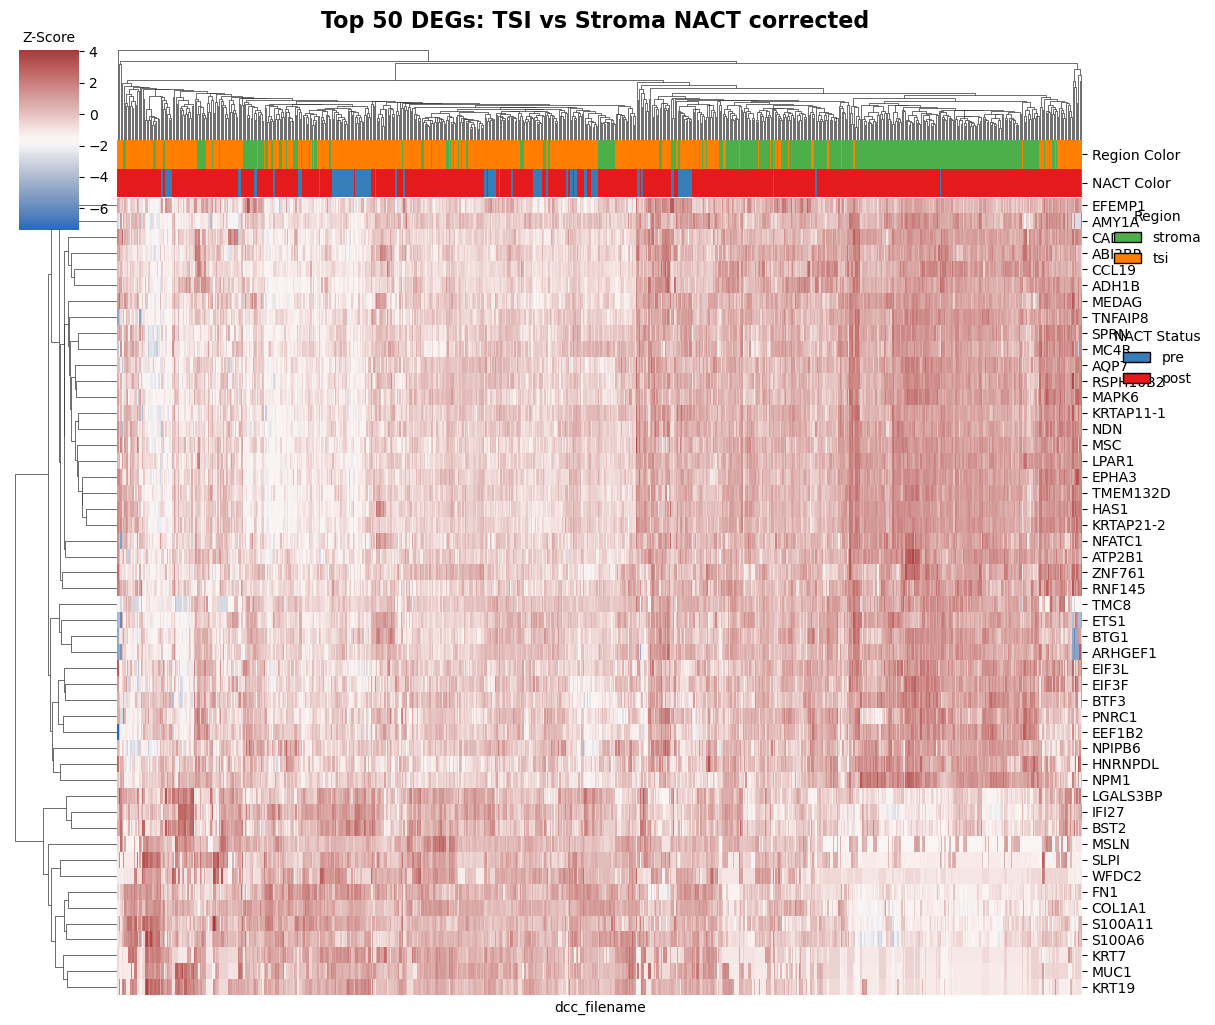

Editable SVG heatmap saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_NACT_corrected.svg


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
results_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_DEG_tsi_stroma_corrected_for_chemo_and_sample.csv"
expr_path = "/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv"
meta_path = "/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.xlsx"

df_results = pd.read_csv(results_path)
raw_expression = pd.read_csv(expr_path)
metadata = pd.read_excel(meta_path, engine='openpyxl')

# --- 2. Get Top Genes ---
# Let's take the top 50 most significant genes by FDR for a clean heatmap
num_genes_to_plot = 50
top_genes = df_results.sort_values('FDR').head(num_genes_to_plot)['Gene'].tolist()

# --- 3. Prep the Data ---
# Merge expression and metadata
df_merged = pd.merge(raw_expression, metadata, on="dcc_filename", how="left")

# Apply the same strict filtering we used for the LMM analysis
df_filtered = df_merged[
    (df_merged['Segment'] == 'stroma') & 
    (df_merged['Segment_geomx'].isin(['stroma', 'tsi']))
].copy()

# Drop rows with missing annotation data so it doesn't break the heatmap
df_filtered = df_filtered.dropna(subset=['Segment_geomx', 'NACT_status'])

# Extract just the top genes for the heatmap matrix
# Set dcc_filename as index so it becomes the column names of the heatmap
heatmap_data = df_filtered.set_index('dcc_filename')[top_genes]

# Transpose so genes are rows and samples are columns (Standard Biology Format)
heatmap_data = heatmap_data.T 

# Convert all data to numeric just in case
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')

# --- 4. Create Annotations (Color Bars) ---
# Extract the metadata for the samples in our heatmap
col_meta = df_filtered.set_index('dcc_filename')[['Segment_geomx', 'NACT_status']]

# Define color dictionaries for your categories
region_colors = {"stroma": "#4daf4a", "tsi": "#ff7f00"}   # Green and Orange
nact_colors = {"pre": "#377eb8", "post": "#e41a1c"}       # Blue and Red

# Map the colors to the samples
col_meta['Region Color'] = col_meta['Segment_geomx'].map(region_colors)
col_meta['NACT Color'] = col_meta['NACT_status'].map(nact_colors)

# The clustermap needs just the color columns
network_colors = col_meta[['Region Color', 'NACT Color']]

# --- 5. Build and Plot the Clustermap ---
# z_score=0 normalizes data across rows (genes) so high/low expressors are on the same visual scale
g = sns.clustermap(
    heatmap_data, 
    cmap="vlag",             # Blue (low) to Red (high) color scale
    z_score=0,               # Z-score normalize across genes
    col_colors=network_colors, 
    figsize=(12, 10), 
    xticklabels=False,       # Hide sample names (too crowded)
    yticklabels=True,        # Show gene names
    cbar_pos=(0.02, 0.8, 0.05, 0.18), # Position of colorbar legend
    dendrogram_ratio=(0.1, 0.1)
)

# Label the colorbar
g.ax_cbar.set_title('Z-Score', fontsize=10)

# --- 6. Add Custom Legends for the Annotations ---
# Because clustermap doesn't auto-legend the top color bars, we add them manually
# Create legend handles for Region
region_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                  for label, color in region_colors.items()]

# Create legend handles for NACT
nact_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                for label, color in nact_colors.items()]

# Add Region Legend
l1 = g.ax_heatmap.legend(
    handles=region_handles, title='Region',
    loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False
)
# Add NACT Legend
l2 = g.ax_heatmap.legend(
    handles=nact_handles, title='NACT Status',
    loc='upper left', bbox_to_anchor=(1.02, 0.85), frameon=False
)
g.ax_heatmap.add_artist(l1) # Keep the first legend when adding the second

# --- 7. Save and Show ---
plt.suptitle(f"Top {num_genes_to_plot} DEGs: TSI vs Stroma NACT corrected", fontsize=16, fontweight='bold', y=1.02)

# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_NACT_corrected.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG heatmap saved successfully to:\n{save_path}")

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


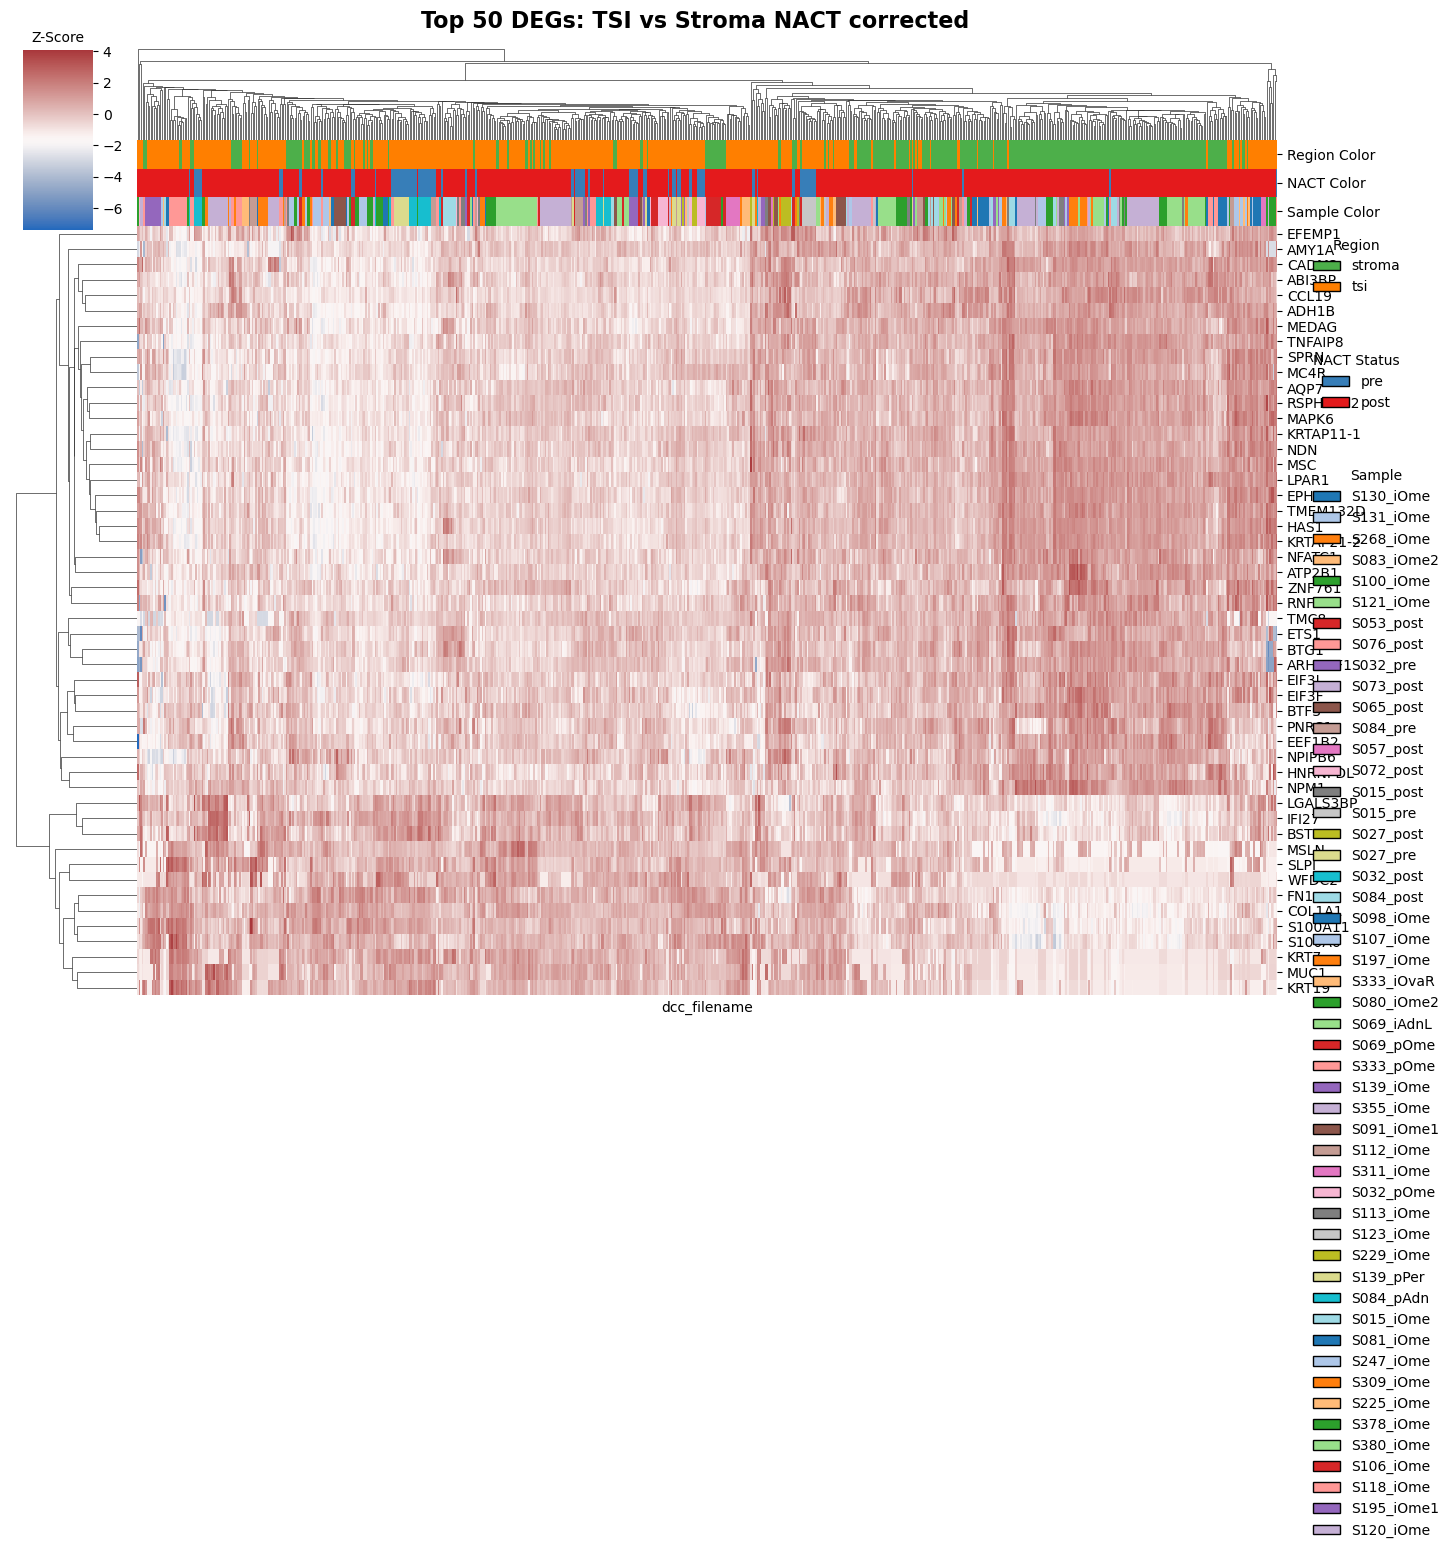

Editable SVG heatmap saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_Python_NACT_corrected_sample_annotated.svg


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
results_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_DEG_tsi_stroma_corrected_for_chemo_and_sample.csv"
expr_path = "/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv"
meta_path = "/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.xlsx"

df_results = pd.read_csv(results_path)
raw_expression = pd.read_csv(expr_path)
metadata = pd.read_excel(meta_path, engine='openpyxl')

# --- 2. Get Top Genes ---
# Let's take the top 50 most significant genes by FDR for a clean heatmap
num_genes_to_plot = 50
top_genes = df_results.sort_values('FDR').head(num_genes_to_plot)['Gene'].tolist()

# --- 3. Prep the Data ---
# Merge expression and metadata
df_merged = pd.merge(raw_expression, metadata, on="dcc_filename", how="left")

# Apply the same strict filtering we used for the LMM analysis
df_filtered = df_merged[
    (df_merged['Segment'] == 'stroma') & 
    (df_merged['Segment_geomx'].isin(['stroma', 'tsi']))
].copy()

# Drop rows with missing annotation data so it doesn't break the heatmap
# Added 'Sample' to the dropna subset
df_filtered = df_filtered.dropna(subset=['Segment_geomx', 'NACT_status', 'Sample'])

# Extract just the top genes for the heatmap matrix
heatmap_data = df_filtered.set_index('dcc_filename')[top_genes]

# Transpose so genes are rows and samples are columns
heatmap_data = heatmap_data.T 

# Convert all data to numeric just in case
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')

# --- 4. Create Annotations (Color Bars) ---
# Extract the metadata for the samples in our heatmap (Now including Sample)
col_meta = df_filtered.set_index('dcc_filename')[['Segment_geomx', 'NACT_status', 'Sample']]

# Define color dictionaries for Region and NACT
region_colors = {"stroma": "#4daf4a", "tsi": "#ff7f00"}   
nact_colors = {"pre": "#377eb8", "post": "#e41a1c"}       

# Dynamically generate colors for Samples
unique_samples = col_meta['Sample'].unique()
sample_palette = sns.color_palette("tab20", n_colors=len(unique_samples)).as_hex()
sample_colors = dict(zip(unique_samples, sample_palette))

# Map the colors to the samples
col_meta['Region Color'] = col_meta['Segment_geomx'].map(region_colors)
col_meta['NACT Color'] = col_meta['NACT_status'].map(nact_colors)
col_meta['Sample Color'] = col_meta['Sample'].map(sample_colors)

# The clustermap needs just the color columns
network_colors = col_meta[['Region Color', 'NACT Color', 'Sample Color']]

# --- 5. Build and Plot the Clustermap ---
g = sns.clustermap(
    heatmap_data, 
    cmap="vlag",             
    z_score=0,               
    col_colors=network_colors, 
    figsize=(14, 10),        # Made slightly wider for the 3 legends
    xticklabels=False,       
    yticklabels=True,        
    cbar_pos=(0.02, 0.8, 0.05, 0.18), 
    dendrogram_ratio=(0.1, 0.1)
)

# Label the colorbar
g.ax_cbar.set_title('Z-Score', fontsize=10)

# --- 6. Add Custom Legends for the Annotations ---
# Create legend handles for Region, NACT, and Sample
region_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                  for label, color in region_colors.items()]

nact_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                for label, color in nact_colors.items()]

sample_handles = [Patch(facecolor=color, label=str(label), edgecolor='black') 
                  for label, color in sample_colors.items()]

# Add Region Legend
l1 = g.ax_heatmap.legend(
    handles=region_handles, title='Region',
    loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False
)
# Add NACT Legend
l2 = g.ax_heatmap.legend(
    handles=nact_handles, title='NACT Status',
    loc='upper left', bbox_to_anchor=(1.02, 0.85), frameon=False
)

# I un-commented this so your Sample legend will show up!
l3 = g.ax_heatmap.legend(
    handles=sample_handles, title='Sample',
    loc='upper left', bbox_to_anchor=(1.02, 0.70), frameon=False
)

# Keep the first two legends when adding the third
g.ax_heatmap.add_artist(l1) 
g.ax_heatmap.add_artist(l2)

# --- 7. Save and Show ---
plt.suptitle(f"Top {num_genes_to_plot} DEGs: TSI vs Stroma NACT corrected", fontsize=16, fontweight='bold', y=1.02)

# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_Python_NACT_corrected_sample_annotated.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG heatmap saved successfully to:\n{save_path}")

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


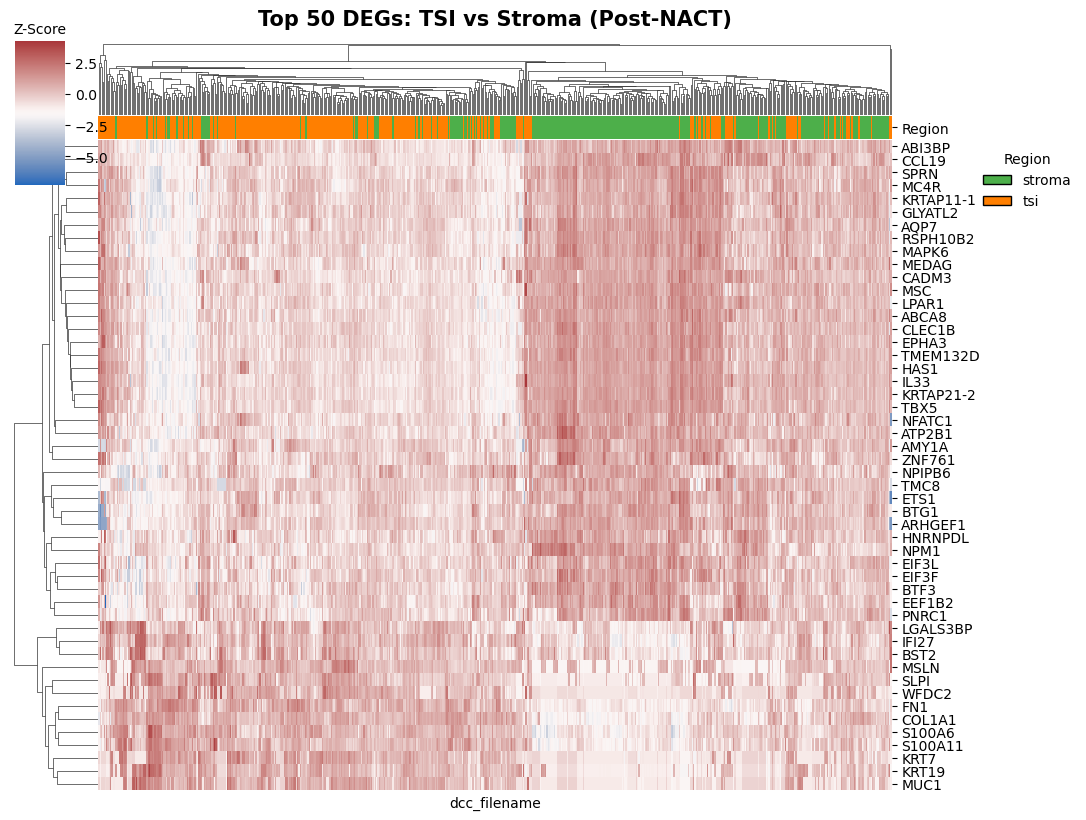

Editable SVG heatmap saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_POST_ONLY.svg


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
results_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_tsi_stroma_POST_ONLY.csv"
expr_path = "/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv"
meta_path = "/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.xlsx"

df_results = pd.read_csv(results_path)
raw_expr = pd.read_csv(expr_path)
metadata = pd.read_excel(meta_path, engine='openpyxl')

# --- 2. Get Top Genes ---
# Extracting the top 50 most significant genes by FDR
top_genes = df_results.sort_values('FDR').head(50)['Gene'].tolist()

# --- 3. Prep the Data ---
df_merged = pd.merge(raw_expr, metadata, on="dcc_filename", how="left")

# Filter for Stroma, TSI, and Post-NACT samples
df_filtered = df_merged[
    (df_merged['Segment'] == 'stroma') & 
    (df_merged['Segment_geomx'].isin(['stroma', 'tsi'])) &
    (df_merged['NACT_status'] == 'post')
].copy()

df_filtered = df_filtered.dropna(subset=['Segment_geomx'])

# Extract top genes, set index to sample IDs, transpose, and ensure numeric format
heatmap_data = df_filtered.set_index('dcc_filename')[top_genes].T.apply(pd.to_numeric)

# --- 4. Create Annotations (Color Bar) ---
region_colors = {"stroma": "#4daf4a", "tsi": "#ff7f00"}
col_colors = df_filtered.set_index('dcc_filename')['Segment_geomx'].map(region_colors)
col_colors.name = "Region"

# --- 5. Build and Plot the Clustermap ---
g = sns.clustermap(
    heatmap_data, 
    cmap="vlag",             
    z_score=0,               # Z-score normalize across genes
    col_colors=col_colors, 
    figsize=(10, 8), 
    xticklabels=False,       
    yticklabels=True,        
    cbar_pos=(0.02, 0.8, 0.05, 0.18), 
    dendrogram_ratio=(0.1, 0.1)
)

g.ax_cbar.set_title('Z-Score', fontsize=10)

# Add Legend manually
legend_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                  for label, color in region_colors.items()]

g.ax_heatmap.legend(
    handles=legend_handles, title='Region',
    loc='upper left', bbox_to_anchor=(1.1, 1), frameon=False
)

# --- 6. Save and Show ---
plt.suptitle("Top 50 DEGs: TSI vs Stroma (Post-NACT)", fontsize=15, fontweight='bold', y=1.02)

# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_POST_ONLY.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG heatmap saved successfully to:\n{save_path}")

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


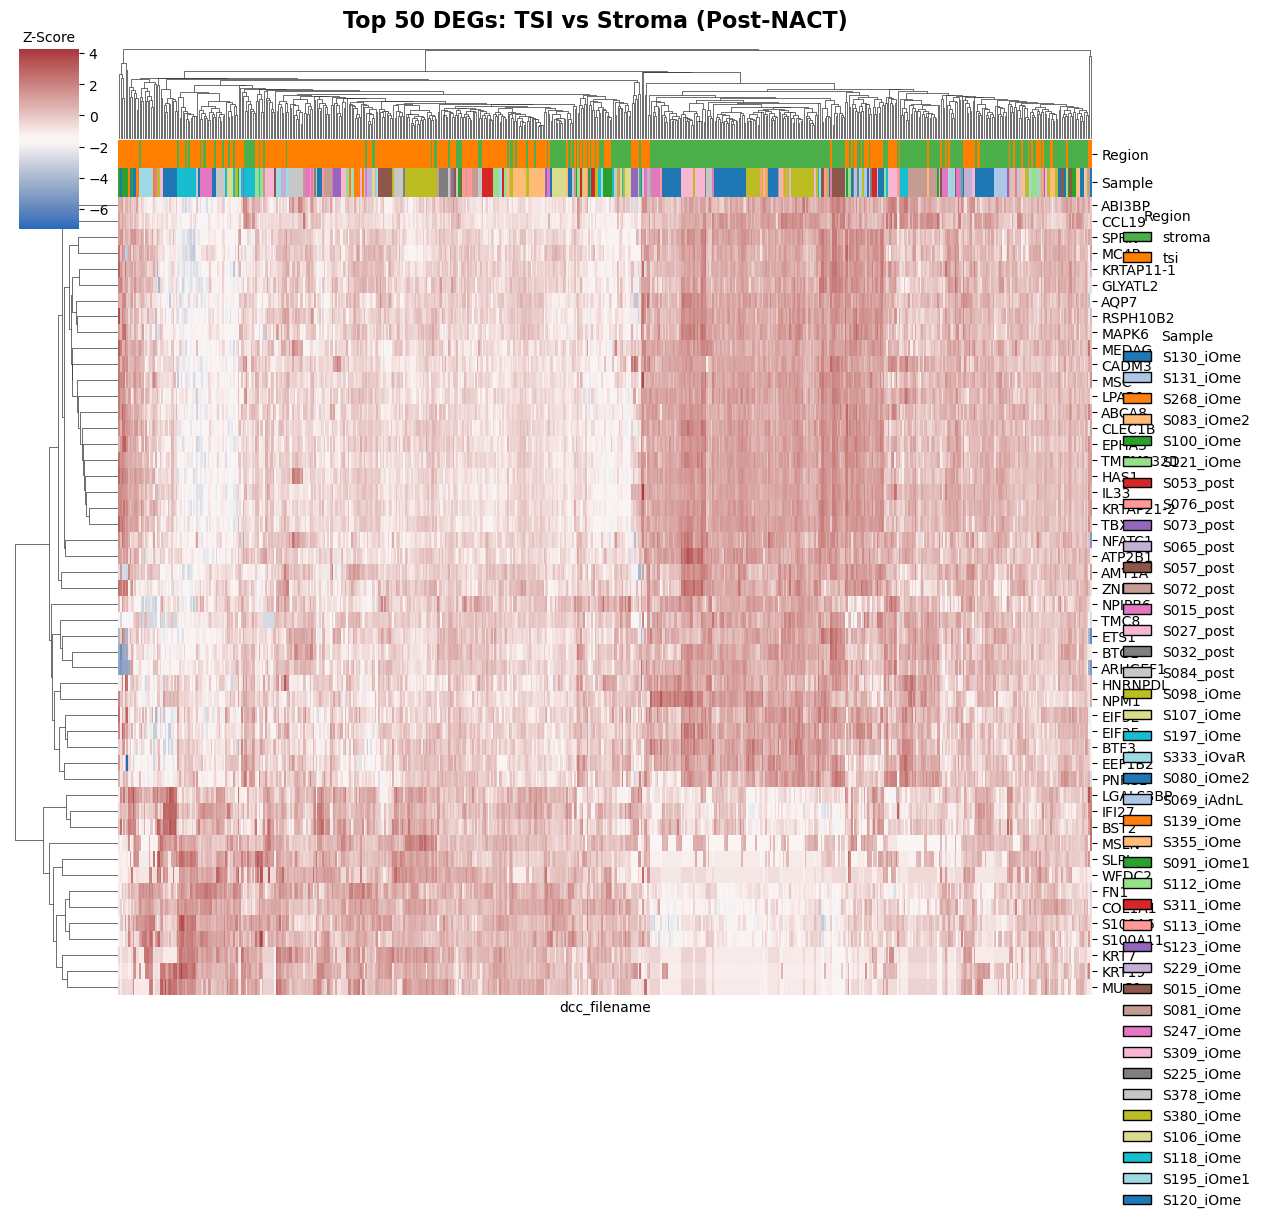

Editable SVG heatmap saved successfully to:
/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_POST_ONLY_with_Samples.svg


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl # <--- Added this import

# --- Tell Matplotlib to keep text editable in vector programs (Affinity/Illustrator) ---
mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['svg.fonttype'] = 'none'  

# --- 1. Load Data ---
results_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/fibroblast_tsi_stroma_POST_ONLY.csv"
expr_path = "/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv"
meta_path = "/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.xlsx"

df_results = pd.read_csv(results_path)
raw_expr = pd.read_csv(expr_path)
metadata = pd.read_excel(meta_path, engine='openpyxl')

# --- 2. Get Top Genes ---
# Extracting the top 50 most significant genes by FDR
top_genes = df_results.sort_values('FDR').head(50)['Gene'].tolist()

# --- 3. Prep the Data ---
df_merged = pd.merge(raw_expr, metadata, on="dcc_filename", how="left")

# Filter for Stroma, TSI, and Post-NACT samples
df_filtered = df_merged[
    (df_merged['Segment'] == 'stroma') & 
    (df_merged['Segment_geomx'].isin(['stroma', 'tsi'])) &
    (df_merged['NACT_status'] == 'post')
].copy()

# Ensure we don't drop rows missing other data if Region and Sample are present
df_filtered = df_filtered.dropna(subset=['Segment_geomx', 'Sample'])

# Extract top genes, set index to sample IDs, transpose, and ensure numeric format
heatmap_data = df_filtered.set_index('dcc_filename')[top_genes].T.apply(pd.to_numeric)

# --- 4. Create Annotations (Color Bars) ---
# Isolate the metadata we need for the color bars
col_meta = df_filtered.set_index('dcc_filename')[['Segment_geomx', 'Sample']]

# 4a. Region Colors
region_colors = {"stroma": "#4daf4a", "tsi": "#ff7f00"}
col_meta['Region'] = col_meta['Segment_geomx'].map(region_colors)

# 4b. Sample Colors (Dynamically generated to handle any number of patients)
unique_samples = col_meta['Sample'].unique()
sample_palette = sns.color_palette("tab20", n_colors=len(unique_samples)).as_hex()
sample_colors = dict(zip(unique_samples, sample_palette))
col_meta['Sample'] = col_meta['Sample'].map(sample_colors)

# Combine them for the clustermap
network_colors = col_meta[['Region', 'Sample']]

# --- 5. Build and Plot the Clustermap ---
g = sns.clustermap(
    heatmap_data, 
    cmap="vlag",             
    z_score=0,               # Z-score normalize across genes
    col_colors=network_colors, # Pass both color columns here
    figsize=(12, 10),        # Made slightly wider to accommodate two legends
    xticklabels=False,       
    yticklabels=True,        
    cbar_pos=(0.02, 0.8, 0.05, 0.18), 
    dendrogram_ratio=(0.1, 0.1)
)

g.ax_cbar.set_title('Z-Score', fontsize=10)

# --- 6. Add Custom Legends ---
# Region Legend
region_handles = [Patch(facecolor=color, label=label, edgecolor='black') 
                  for label, color in region_colors.items()]

l1 = g.ax_heatmap.legend(
    handles=region_handles, title='Region',
    loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False
)

# Sample Legend
sample_handles = [Patch(facecolor=color, label=str(label), edgecolor='black') 
                  for label, color in sample_colors.items()]

# Removed the ''' quotes so this legend is activated
l2 = g.ax_heatmap.legend(
    handles=sample_handles, title='Sample',
    loc='upper left', bbox_to_anchor=(1.02, 0.85), frameon=False # Placed below the Region legend
)

# Keep the first legend active when adding the second
g.ax_heatmap.add_artist(l1)

# --- 7. Save and Show ---
plt.suptitle("Top 50 DEGs: TSI vs Stroma (Post-NACT)", fontsize=16, fontweight='bold', y=1.02)

# Changed filename extension to .svg and explicitly set format='svg'
save_path = "/Users/nikamikhailava/Desktop/Fibroblasts_signature_derivation/Heatmap_TSI_vs_Stroma_POST_ONLY_with_Samples.svg"
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()

print(f"Editable SVG heatmap saved successfully to:\n{save_path}")